In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv('placement (1).csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [3]:
X = df.iloc[:,0:1]
y= df.iloc[:,1:]

In [4]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [7]:
print(f"y_trainshape{y_train.shape}")
print(f"xtrainshape{X_train.shape}")


y_trainshape(160, 1)
xtrainshape(160, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42)

Text(0, 0.5, 'Package')

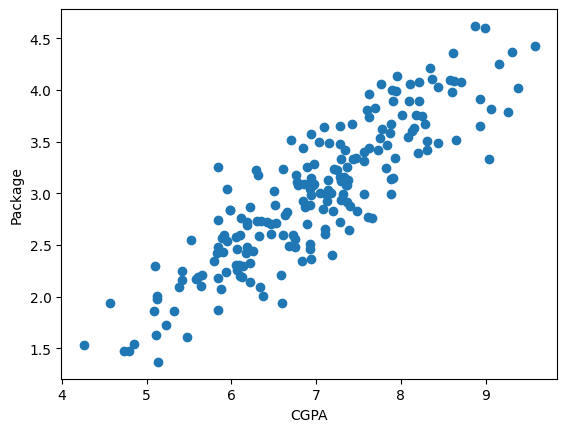

In [8]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
X_test.iloc[0].shape

(1,)

In [12]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

c:\MACHINE LEARNING ADVANCE\mlenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[2.78031348]])

Text(0, 0.5, 'Package')

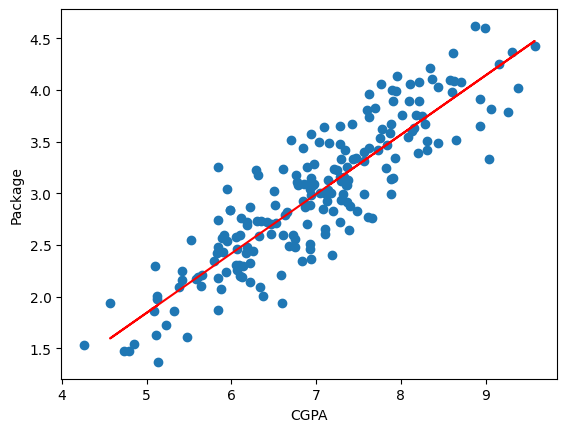

In [13]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), c= 'red')
plt.xlabel('CGPA')
plt.ylabel('Package')

In [14]:
m = lr.coef_
m

array([[0.57425647]])

In [15]:
b = lr.intercept_
b

array([-1.02700694])

### MAKING LINEAR REGRESSION FROM SCRATCH 

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [17]:
class Meralr():
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self, X_train, y_train):
        num =0
        den =0
        for i in range(X_train.shape[0]):
            num = num + ( X_train[i]-X_train.mean())  * (y_train[i] - y_train.mean())
            den = den +  ( X_train[i]-X_train.mean()) * ( X_train[i]-X_train.mean()) 
            
        self .m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        
    
    def predict(self,X_test):
        return  self.m * X_test + self.b

In [18]:
df = pd.read_csv(r'placement (1).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [19]:
X = df.iloc[:,0].values
y= df.iloc[:,-1].values

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=42)

In [21]:
X_train.shape

(160,)

In [22]:
lr  = Meralr()
lr.fit(X_train,y_train)

In [23]:
x= lr.predict(X_test)
x

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

### METRICS 

In [24]:

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [25]:

y_pred = lr.predict(X_test)

In [27]:
y_test

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [28]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.23150985393278373


In [30]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.08417638361329656


In [29]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.2901316659954521
